In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [5]:
df=pd.read_csv('C:/Users/X/Desktop/penguins.csv')
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0,FEMALE
341,50.4,15.7,222.0,5750.0,MALE
342,45.2,14.8,212.0,5200.0,FEMALE


In [7]:
indices_to_remove=[]
for index,row in df.iterrows():
    print(index)
    print(row)

0
culmen_length_mm       39.1
culmen_depth_mm        18.7
flipper_length_mm     181.0
body_mass_g          3750.0
sex                    MALE
Name: 0, dtype: object
1
culmen_length_mm       39.5
culmen_depth_mm        17.4
flipper_length_mm     186.0
body_mass_g          3800.0
sex                  FEMALE
Name: 1, dtype: object
2
culmen_length_mm       40.3
culmen_depth_mm        18.0
flipper_length_mm     195.0
body_mass_g          3250.0
sex                  FEMALE
Name: 2, dtype: object
3
culmen_length_mm     NaN
culmen_depth_mm      NaN
flipper_length_mm    NaN
body_mass_g          NaN
sex                  NaN
Name: 3, dtype: object
4
culmen_length_mm       36.7
culmen_depth_mm        19.3
flipper_length_mm     193.0
body_mass_g          3450.0
sex                  FEMALE
Name: 4, dtype: object
5
culmen_length_mm       39.3
culmen_depth_mm        20.6
flipper_length_mm     190.0
body_mass_g          3650.0
sex                    MALE
Name: 5, dtype: object
6
culmen_length_mm       

In [10]:
indices_to_remove=[]
for index,row in df.iterrows():
    if row.isna().any():
        indices_to_remove.append(index)
df=df.drop(indices_to_remove)
df=df.reset_index(drop=True)
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...
330,47.2,13.7,214.0,4925.0,FEMALE
331,46.8,14.3,215.0,4850.0,FEMALE
332,50.4,15.7,222.0,5750.0,MALE
333,45.2,14.8,212.0,5200.0,FEMALE


In [13]:
df=df[~(df['sex']=='.')]
df=df.reset_index(drop=True)
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...
329,47.2,13.7,214.0,4925.0,FEMALE
330,46.8,14.3,215.0,4850.0,FEMALE
331,50.4,15.7,222.0,5750.0,MALE
332,45.2,14.8,212.0,5200.0,FEMALE


In [20]:
max_body_mass=df['body_mass_g'].max()
df=df[~(df['body_mass_g']==max_body_mass)]
df=df.reset_index(drop=True)
df
#alternative: remove extreme values using quantiles
q=df['body_mass_g'].quantile(0.99)
df=df[df['body_mass_g']<=q]
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...
325,47.2,13.7,214.0,4925.0,FEMALE
326,46.8,14.3,215.0,4850.0,FEMALE
327,50.4,15.7,222.0,5750.0,MALE
328,45.2,14.8,212.0,5200.0,FEMALE


In [ ]:
df['flipper_length_mm'].mean()


np.float64(214.16768292682926)

In [27]:
q_low=df['flipper_length_mm'].quantile(0.01)
q_high=df['flipper_length_mm'].quantile(0.99)
df=df[(df['flipper_length_mm']>=q_low) & (df['flipper_length_mm']<=q_high)]
df=df.reset_index(drop=True)
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,36.7,19.3,193.0,3450.0,FEMALE
4,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...
309,47.2,13.7,214.0,4925.0,FEMALE
310,46.8,14.3,215.0,4850.0,FEMALE
311,50.4,15.7,222.0,5750.0,MALE
312,45.2,14.8,212.0,5200.0,FEMALE


In [30]:
sex_counts = df['sex'].value_counts()
sex_counts
print("Number of Males:", sex_counts['MALE'])
print("Number of Females:", sex_counts['FEMALE'])

Number of Males: 156
Number of Females: 158


In [32]:
numerical_features=df.drop('sex',axis=1)
numerical_features

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,36.7,19.3,193.0,3450.0
4,39.3,20.6,190.0,3650.0
...,...,...,...,...
309,47.2,13.7,214.0,4925.0
310,46.8,14.3,215.0,4850.0
311,50.4,15.7,222.0,5750.0
312,45.2,14.8,212.0,5200.0


<Axes: >

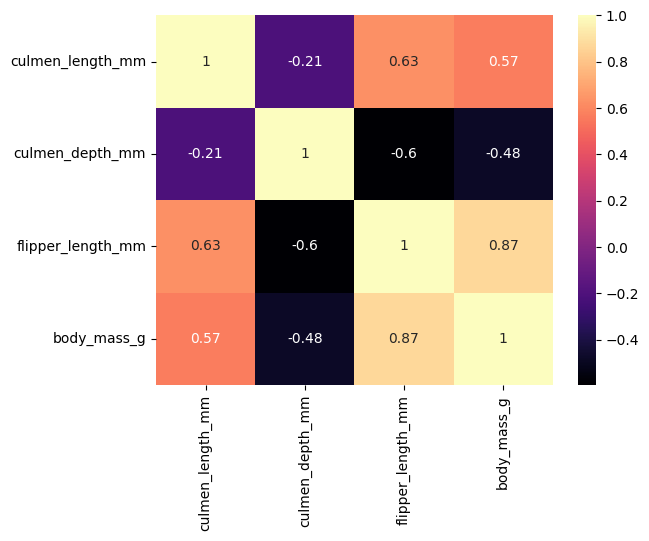

In [36]:
sns.heatmap(df.corr(numeric_only=True),cmap='magma',annot=True)

In [39]:
#Standardize the data
scaler=StandardScaler()
numerical_features_scaled=scaler.fit_transform(numerical_features)
numerical_features_scaled

array([[-0.92154653,  0.77629852, -1.53176383, -0.57529416],
       [-0.84680402,  0.12427166, -1.15363974, -0.51029151],
       [-0.69731901,  0.42520713, -0.47301638, -1.22532067],
       ...,
       [ 1.18992925, -0.72837886,  1.56885371,  2.02481188],
       [ 0.21827668, -1.17978207,  0.81260553,  1.30978271],
       [ 1.09650112, -0.52775521,  0.88823035,  1.56979332]])

In [41]:
cov_matr_num=np.cov(numerical_features_scaled.T)
cov_matr_num

array([[ 1.00319489, -0.21241451,  0.63405857,  0.57020159],
       [-0.21241451,  1.00319489, -0.59730899, -0.48318049],
       [ 0.63405857, -0.59730899,  1.00319489,  0.87391505],
       [ 0.57020159, -0.48318049,  0.87391505,  1.00319489]])

array([2.73797879, 0.79429884, 0.37295042, 0.10755149])

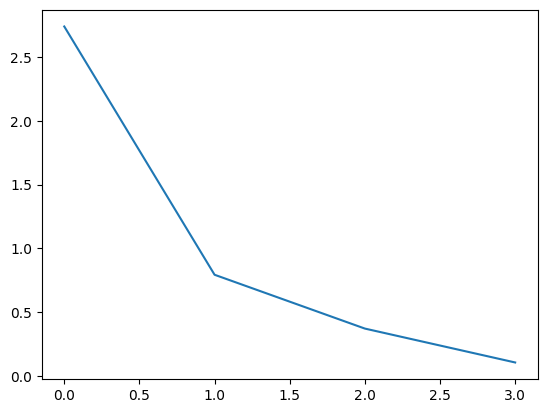

In [43]:
eigenvals,eigenvecs=np.linalg.eig(cov_matr_num)
plt.plot(eigenvals)
eigenvals

In [54]:
transformer=PCA(2)
numerical_features_trans=transformer.fit_transform(numerical_features)
transformer.components_

array([[ 0.00395444, -0.0012484 ,  0.01497481,  0.99987927],
       [ 0.33704123, -0.09562453,  0.93649324, -0.01547786]])

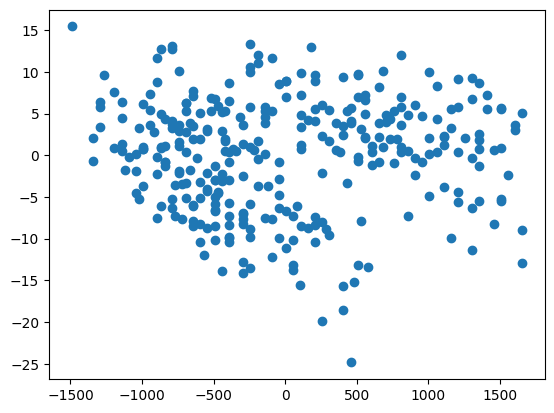

In [55]:
plt.scatter(*numerical_features_trans.T)